 Q-1

In [ ]:
import numpy as np
data_points = np.array([
    [2, 3],  # Point A
    [3, 4],  # Point B
    [6, 6],  # Point C
    [7, 7]   # Point D
])
centroids = np.array([
    data_points[0],  
    data_points[2]  
])
print("Data Points:\n", data_points)
print("\nInitial Centroids:\n", centroids)

Data Points:
 [[2 3]
 [3 4]
 [6 6]
 [7 7]]

Initial Centroids:
 [[2 3]
 [6 6]]


In [ ]:
def calculate_distances(point, centroids):
    return np.array([np.linalg.norm(point - centroid) for centroid in centroids])
def assign_to_clusters(data_points, centroids):
    assignments = []
    for point in data_points:
        distances = calculate_distances(point, centroids)
        assignments.append(np.argmin(distances))
    return np.array(assignments)
def update_centroids(data_points, assignments, num_centroids):
    new_centroids = np.zeros((num_centroids, data_points.shape[1]))
    for i in range(num_centroids):
        points_in_cluster = data_points[assignments == i]
        if len(points_in_cluster) > 0:
            new_centroids[i] = np.mean(points_in_cluster, axis=0)
        else:
            # Handle empty cluster: keep the old centroid or re-initialize
            # For this simple example, we'll keep the old centroid
            pass # This case will be handled by the main loop, if needed
    return new_centroids

print("K-Means helper functions defined: calculate_distances, assign_to_clusters, update_centroids")

K-Means helper functions defined: calculate_distances, assign_to_clusters, update_centroids


In [ ]:
max_iterations = 10
previous_centroids = None
num_centroids = len(centroids)

print("\nStarting K-Means iterations...")

for i in range(max_iterations):
    print(f"\n--- Iteration {i+1} ---")

    assignments = assign_to_clusters(data_points, centroids)
    print("Current Centroids:\n", centroids)
    print("Cluster Assignments:", assignments)

    new_centroids = update_centroids(data_points, assignments, num_centroids)

    if previous_centroids is not None and np.array_equal(new_centroids, previous_centroids):
        print("Centroids converged. Stopping iterations.")
        break

    previous_centroids = centroids.copy()
    centroids = new_centroids

    print("Updated Centroids:\n", centroids)

print("\nFinal Centroids after convergence:\n", centroids)
print("Final Cluster Assignments:", assign_to_clusters(data_points, centroids))


Starting K-Means iterations...

--- Iteration 1 ---
Current Centroids:
 [[2 3]
 [6 6]]
Cluster Assignments: [0 0 1 1]
Updated Centroids:
 [[2.5 3.5]
 [6.5 6.5]]

--- Iteration 2 ---
Current Centroids:
 [[2.5 3.5]
 [6.5 6.5]]
Cluster Assignments: [0 0 1 1]
Updated Centroids:
 [[2.5 3.5]
 [6.5 6.5]]

--- Iteration 3 ---
Current Centroids:
 [[2.5 3.5]
 [6.5 6.5]]
Cluster Assignments: [0 0 1 1]
Centroids converged. Stopping iterations.

Final Centroids after convergence:
 [[2.5 3.5]
 [6.5 6.5]]
Final Cluster Assignments: [0 0 1 1]


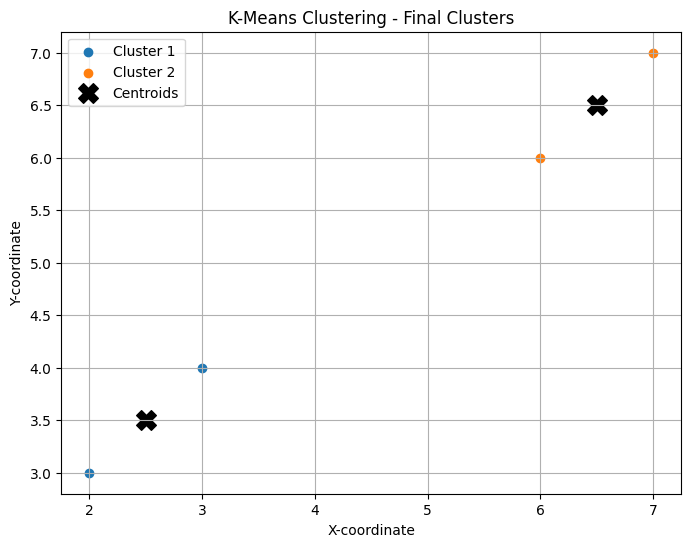

In [ ]:
import matplotlib.pyplot as plt

final_assignments = assign_to_clusters(data_points, centroids)

plt.figure(figsize=(8, 6))

for i in range(num_centroids):
    points_in_cluster = data_points[final_assignments == i]
    plt.scatter(points_in_cluster[:, 0], points_in_cluster[:, 1], label=f'Cluster {i+1}')

plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', label='Centroids')

plt.title('K-Means Clustering - Final Clusters')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.legend()
plt.grid(True)
plt.show()

# Q-2

In [6]:
data_points = np.array([
    [2, 4, 10],
    [12, 3, 20],
    [13, 11, 25]
])

centroids = np.array([
    [2, 4, 10],
    [12, 3, 20]
])

print("New Data Points:\n", data_points)
print("\nNew Initial Centroids:\n", centroids)

New Data Points:
 [[ 2  4 10]
 [12  3 20]
 [13 11 25]]

New Initial Centroids:
 [[ 2  4 10]
 [12  3 20]]


In [ ]:
max_iterations = 10
previous_centroids = None
num_centroids = len(centroids)

print("\nStarting K-Means iterations for 3D data...")

for i in range(max_iterations):
    print(f"\n--- Iteration {i+1} ---")

    assignments = assign_to_clusters(data_points, centroids)
    print("Current Centroids:\n", centroids)
    print("Cluster Assignments:", assignments)

    new_centroids = update_centroids(data_points, assignments, num_centroids)

    if previous_centroids is not None and np.array_equal(new_centroids, previous_centroids):
        print("Centroids converged. Stopping iterations.")
        break

    previous_centroids = centroids.copy()
    centroids = new_centroids

    print("Updated Centroids:\n", centroids)

print("\nFinal Centroids after convergence:\n", centroids)
print("Final Cluster Assignments:", assign_to_clusters(data_points, centroids))


Starting K-Means iterations for 3D data...

--- Iteration 1 ---
Current Centroids:
 [[ 2  4 10]
 [12  3 20]]
Cluster Assignments: [0 1 1]
Updated Centroids:
 [[ 2.   4.  10. ]
 [12.5  7.  22.5]]

--- Iteration 2 ---
Current Centroids:
 [[ 2.   4.  10. ]
 [12.5  7.  22.5]]
Cluster Assignments: [0 1 1]
Updated Centroids:
 [[ 2.   4.  10. ]
 [12.5  7.  22.5]]

--- Iteration 3 ---
Current Centroids:
 [[ 2.   4.  10. ]
 [12.5  7.  22.5]]
Cluster Assignments: [0 1 1]
Centroids converged. Stopping iterations.

Final Centroids after convergence:
 [[ 2.   4.  10. ]
 [12.5  7.  22.5]]
Final Cluster Assignments: [0 1 1]


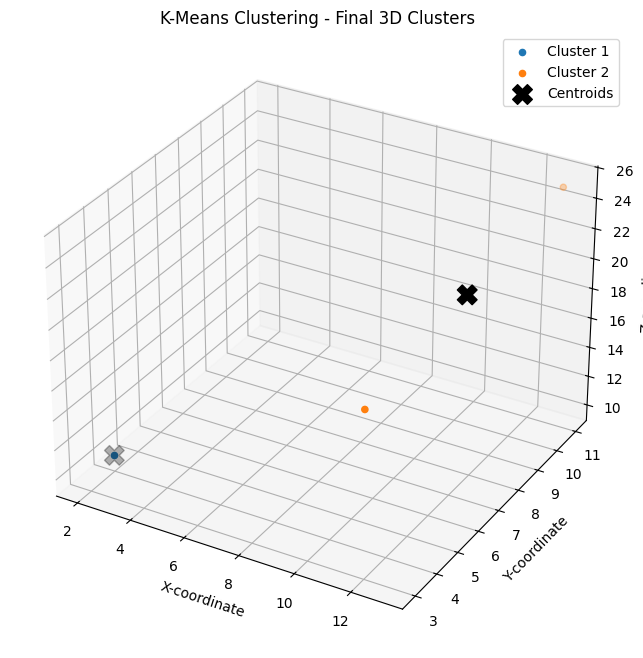

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get final assignments after convergence (from the previous step)
final_assignments = assign_to_clusters(data_points, centroids)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points colored by cluster assignment
for i in range(num_centroids):
    points_in_cluster = data_points[final_assignments == i]
    ax.scatter(points_in_cluster[:, 0], points_in_cluster[:, 1], points_in_cluster[:, 2], label=f'Cluster {i+1}')

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker='X', s=200, color='black', label='Centroids')

ax.set_title('K-Means Clustering - Final 3D Clusters')
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')
ax.set_zlabel('Z-coordinate')
ax.legend()
plt.grid(True)
plt.show()
